# AQI Prediction — Full ML Pipeline

**Objective**: Predict Air Quality Index (AQI) from pollutant concentrations across Indian cities.

## Pipeline Overview
1. **EDA** — Explore data, missing values, distributions
2. **Preprocessing** — Imputation, feature engineering, scaling
3. **Model Training** — Linear, Ridge, Lasso, RF, XGBoost, LightGBM, CatBoost
4. **Hyperparameter Tuning** — RandomizedSearchCV
5. **City-Specific vs Global** — Compare per-city vs pooled model
6. **SHAP Interpretability** — Global & per-city feature importance
7. **Forecasting** — Lag-based future AQI prediction
8. **Save Artifacts** — Model, scaler, encoders for dashboard

In [18]:
# ============================================================
# IMPORTS
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from datetime import datetime

# Preprocessing
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# SHAP
import shap

np.random.seed(42)

# Paths
BASE_DIR = os.path.dirname(os.getcwd())
RAW_DATA_PATH = os.path.join(BASE_DIR, 'data', 'raw', 'city_day.csv')
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
FIGURES_DIR = os.path.join(BASE_DIR, 'docs', 'figures')

for d in [PROCESSED_DIR, MODELS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print('All imports successful. Directories ready.')

All imports successful. Directories ready.


---
## PHASE 1: EDA & DATA EXPLORATION

In [19]:
# ============================================================
# 1.1 LOAD & INITIAL INSPECTION
# ============================================================
df = pd.read_csv(RAW_DATA_PATH)
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nData types:')
print(df.dtypes)
print(f'\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

Dataset shape: (29531, 16)
Columns: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Data types:
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

Memory usage: 7.71 MB



=== Missing Values ===
            Missing Count  Percentage
Xylene              18109   61.322001
PM10                11140   37.723071
NH3                 10328   34.973418
Toluene              8041   27.229014
Benzene              5623   19.041008
AQI                  4681   15.851139
AQI_Bucket           4681   15.851139
PM2.5                4598   15.570079
NOx                  4185   14.171549
O3                   4022   13.619586
SO2                  3854   13.050692
NO2                  3585   12.139785
NO                   3582   12.129626
CO                   2059    6.972334


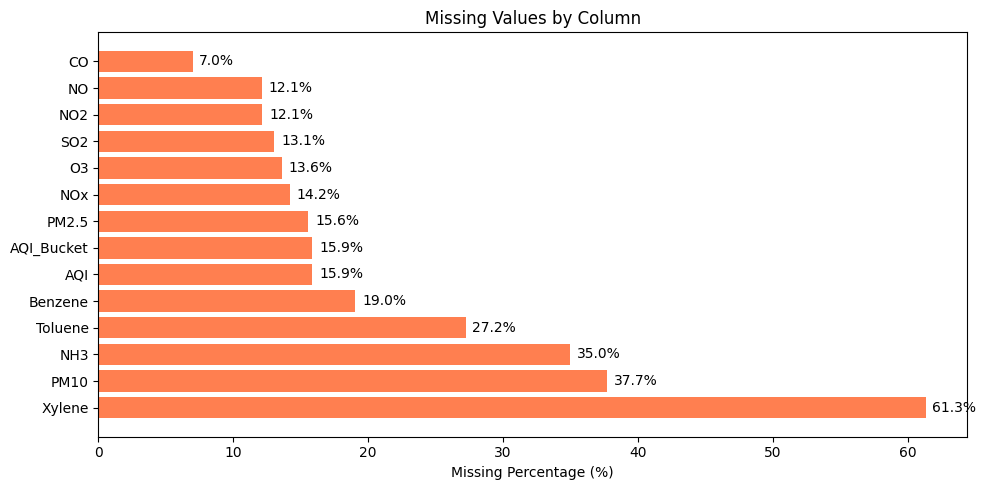

In [20]:
# ============================================================
# 1.2 MISSING DATA ANALYSIS
# ============================================================
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False)
print('\n=== Missing Values ===')
print(missing_df)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_df.index, missing_df['Percentage'], color='coral')
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Values by Column')
for bar, pct in zip(bars, missing_df['Percentage']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', va='center')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_missing_values.png'), dpi=150)
plt.show()


=== Cities & Row Counts ===
City
Ahmedabad             2009
Bengaluru             2009
Chennai               2009
Mumbai                2009
Lucknow               2009
Delhi                 2009
Hyderabad             2006
Patna                 1858
Gurugram              1679
Visakhapatnam         1462
Amritsar              1221
Jorapokhar            1169
Jaipur                1114
Thiruvananthapuram    1112
Amaravati              951
Brajrajnagar           938
Talcher                925
Kolkata                814
Guwahati               502
Coimbatore             386
Shillong               310
Chandigarh             304
Bhopal                 289
Kochi                  162
Ernakulam              162
Aizawl                 113
Name: count, dtype: int64

Total cities: 26
Cities with >= 100 rows: 26
Cities with < 100 rows: 0

Cities with < 100 rows: []


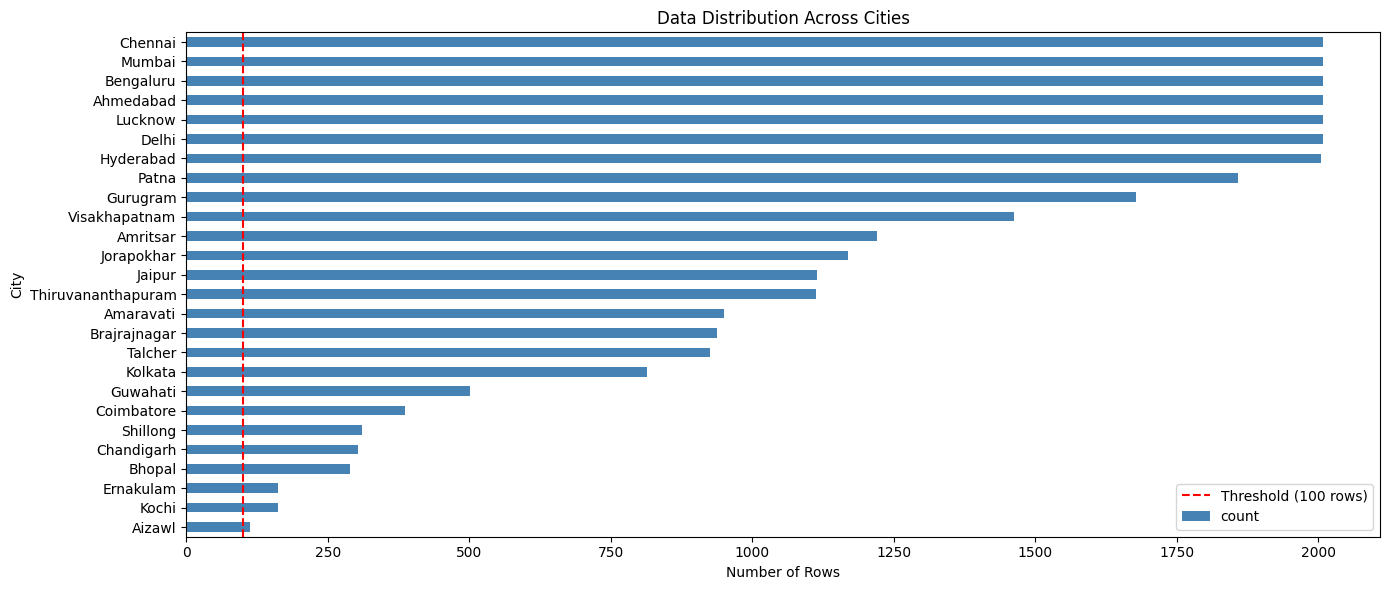

In [21]:
# ============================================================
# 1.3 CITY-WISE ANALYSIS
# ============================================================
city_counts = df['City'].value_counts()
print('\n=== Cities & Row Counts ===')
print(city_counts)
print(f'\nTotal cities: {len(city_counts)}')
print(f'Cities with >= 100 rows: {(city_counts >= 100).sum()}')
print(f'Cities with < 100 rows: {(city_counts < 100).sum()}')
print(f'\nCities with < 100 rows: {list(city_counts[city_counts < 100].index)}')

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
city_counts.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(x=100, color='red', linestyle='--', label='Threshold (100 rows)')
ax.set_xlabel('Number of Rows')
ax.set_ylabel('City')
ax.set_title('Data Distribution Across Cities')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_city_distribution.png'), dpi=150)
plt.show()


=== Descriptive Statistics ===
              PM2.5          PM10            NO           NO2           NOx  \
count  24933.000000  18391.000000  25949.000000  25946.000000  25346.000000   
mean      67.450578    118.127103     17.574730     28.560659     32.309123   
std       64.661449     90.605110     22.785846     24.474746     31.646011   
min        0.040000      0.010000      0.020000      0.010000      0.000000   
25%       28.820000     56.255000      5.630000     11.750000     12.820000   
50%       48.570000     95.680000      9.890000     21.690000     23.520000   
75%       80.590000    149.745000     19.950000     37.620000     40.127500   
max      949.990000   1000.000000    390.680000    362.210000    467.630000   

                NH3            CO           SO2            O3       Benzene  \
count  19203.000000  27472.000000  25677.000000  25509.000000  23908.000000   
mean      23.483476      2.248598     14.531977     34.491430      3.280840   
std       25.684275

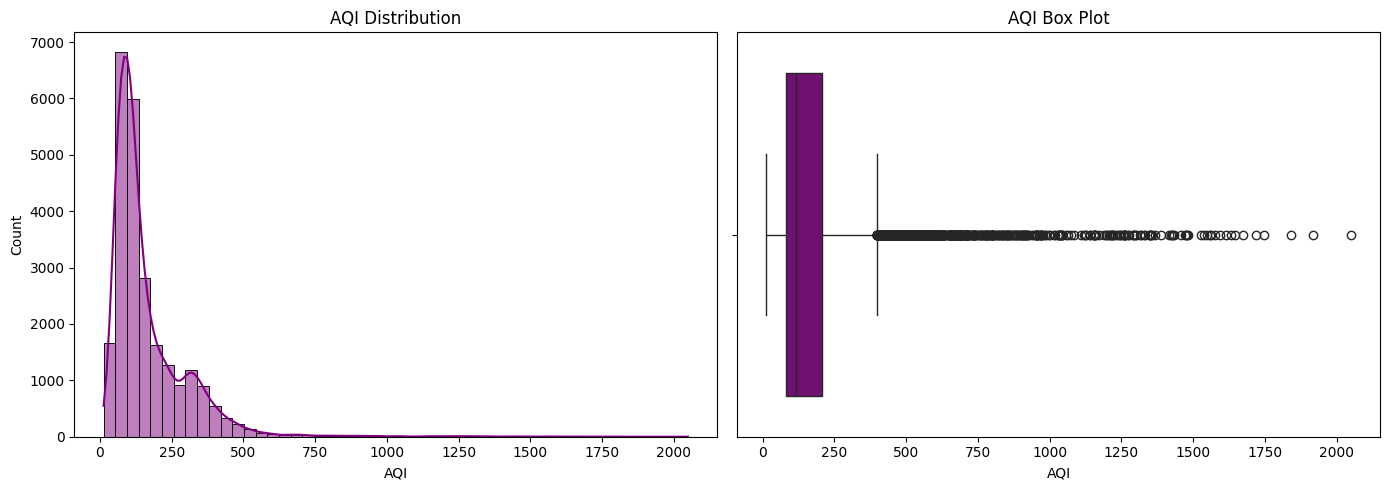

In [22]:
# ============================================================
# 1.4 AQI & POLLUTANT DISTRIBUTIONS
# ============================================================
pollution_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']
available_poll = [c for c in pollution_cols if c in df.columns]

print('\n=== Descriptive Statistics ===')
print(df[available_poll].describe())

# AQI Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['AQI'].dropna(), bins=50, kde=True, ax=axes[0], color='purple')
axes[0].set_title('AQI Distribution')
axes[0].set_xlabel('AQI')
sns.boxplot(x=df['AQI'].dropna(), ax=axes[1], color='purple')
axes[1].set_title('AQI Box Plot')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_aqi_distribution.png'), dpi=150)
plt.show()

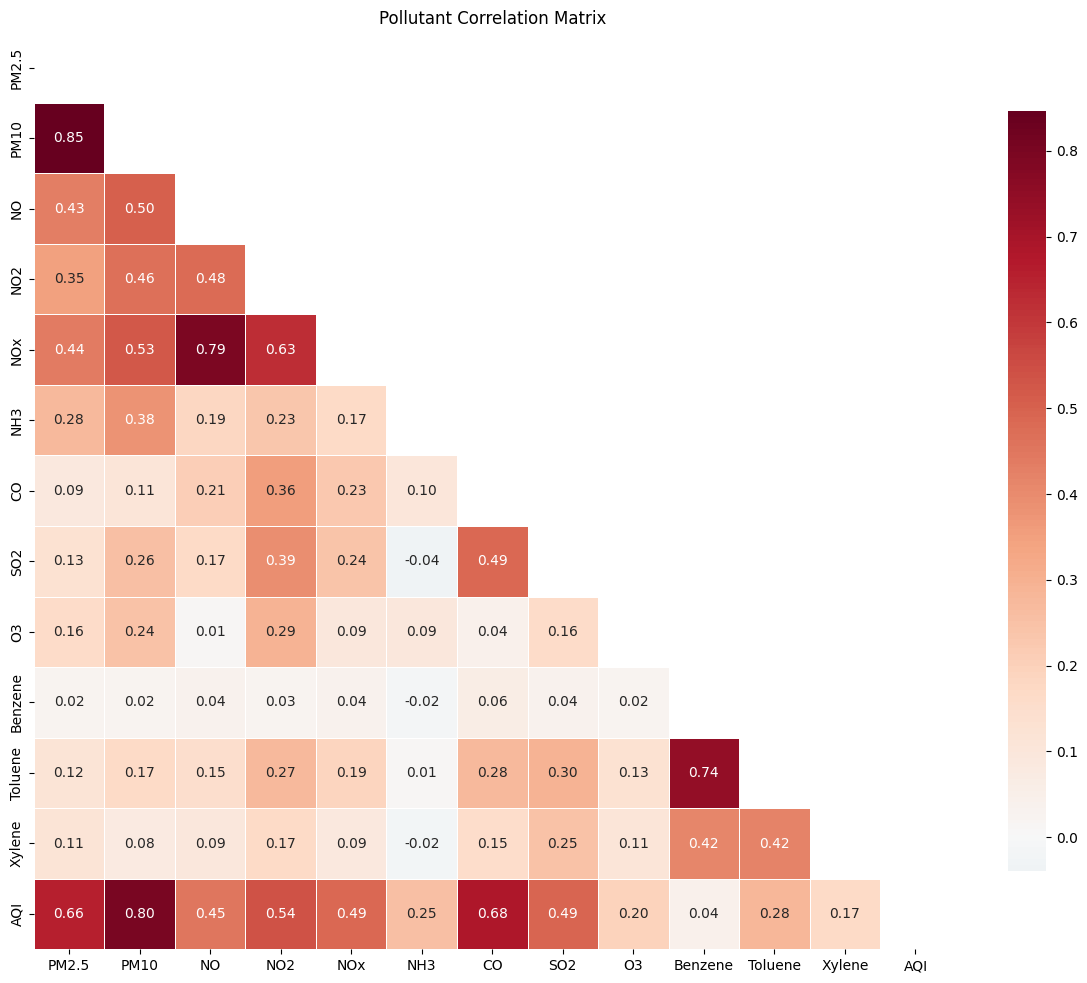


=== Correlation with AQI (descending) ===
PM10       0.803313
CO         0.683346
PM2.5      0.659181
NO2        0.537071
SO2        0.490586
NOx        0.486450
NO         0.452191
Toluene    0.279992
NH3        0.252019
O3         0.198991
Xylene     0.165532
Benzene    0.044407
Name: AQI, dtype: float64


In [23]:
# ============================================================
# 1.5 CORRELATION ANALYSIS
# ============================================================
corr = df[available_poll].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Pollutant Correlation Matrix')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_correlation_matrix.png'), dpi=150)
plt.show()

# AQI correlations
aqi_corr = corr['AQI'].drop('AQI').sort_values(ascending=False)
print('\n=== Correlation with AQI (descending) ===')
print(aqi_corr)

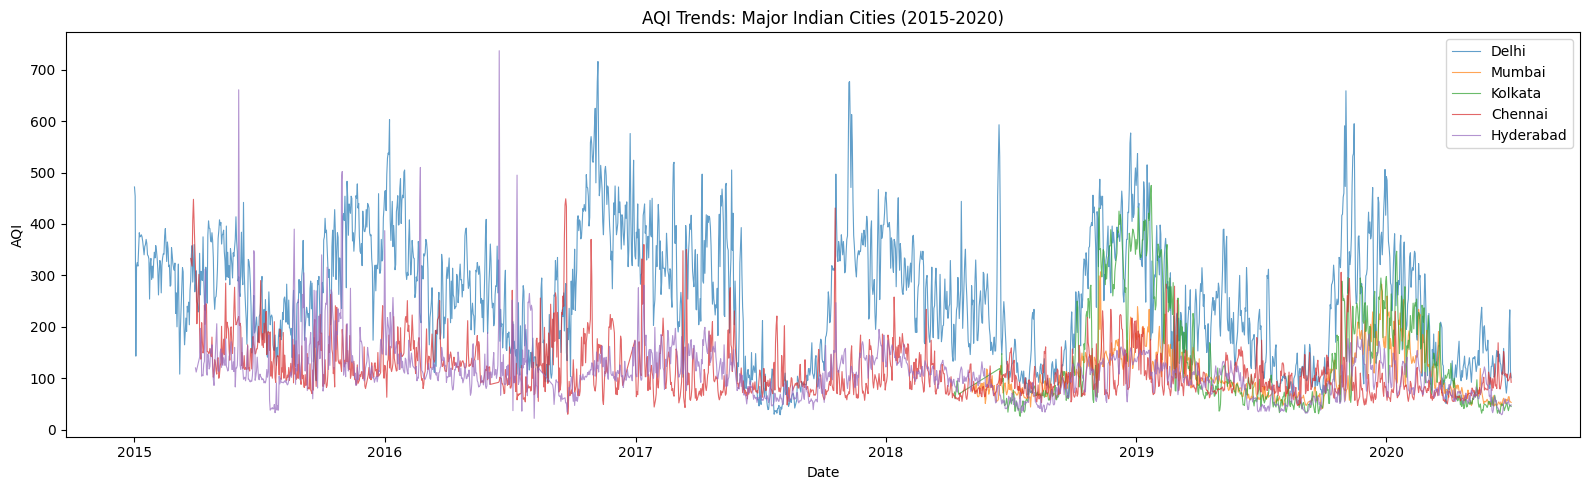

In [24]:
# ============================================================
# 1.6 TIME SERIES: AQI OVER TIME
# ============================================================
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df_sorted = df.sort_values('Date').dropna(subset=['Date', 'AQI'])

fig, ax = plt.subplots(figsize=(16, 5))
for city in ['Delhi', 'Mumbai', 'Kolkata', 'Chennai', 'Bangalore', 'Hyderabad']:
    city_data = df_sorted[df_sorted['City'] == city]
    if len(city_data) > 10:
        ax.plot(city_data['Date'], city_data['AQI'], label=city, alpha=0.7, linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('AQI')
ax.set_title('AQI Trends: Major Indian Cities (2015-2020)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05_aqi_trends.png'), dpi=150)
plt.show()

---
## PHASE 2: DATA PREPROCESSING & FEATURE ENGINEERING

In [25]:
# ============================================================
# 2.1 IMPUTATION: COMPARE METHODS
# ============================================================
# Make a copy for this section
df_work = df.copy()

# Strategy 1: City-wise mean imputation (baseline from original project)
df_city_mean = df_work.copy()
poll_cols = [c for c in available_poll if c != 'AQI']
for col in poll_cols:
    df_city_mean[col] = df_city_mean.groupby('City')[col].transform(lambda x: x.fillna(x.mean()))
# Then fill any remaining NaN with overall mean
for col in poll_cols:
    df_city_mean[col] = df_city_mean[col].fillna(df_city_mean[col].mean())

# Strategy 2: KNN Imputer (using only numeric columns grouped by city)
# We'll use a simpler approach that works well
df_knn = df_work.copy()
city_groups = df_knn.groupby('City')
for city, group in city_groups:
    if len(group) > 1:
        idx = group.index
        subset = group[poll_cols].copy()
        if subset.isnull().any().any():
            imputer = KNNImputer(n_neighbors=min(5, len(subset)-1))
            valid_cols = [c for c in subset.columns if subset[c].notna().any()]
            if len(valid_cols) == 0:
                continue
            imputer = KNNImputer(n_neighbors=min(5, len(subset)-1))
            imputed = pd.DataFrame(imputer.fit_transform(subset[valid_cols]), columns=valid_cols, index=idx)
            df_knn.loc[idx, valid_cols] = imputed
# Fill remaining
for col in poll_cols:
    df_knn[col] = df_knn[col].fillna(df_knn[col].mean())

# Compare
print('=== Imputation Comparison ===')
print(f'City-Mean: remaining NaN after = {df_city_mean[poll_cols].isnull().sum().sum()}')
print(f'KNN: remaining NaN after = {df_knn[poll_cols].isnull().sum().sum()}')

# Use KNN as default
df_imputed = df_knn.copy()
print('\nUsing KNN Imputer (better for multivariate relationships).')

=== Imputation Comparison ===
City-Mean: remaining NaN after = 0
KNN: remaining NaN after = 0

Using KNN Imputer (better for multivariate relationships).


In [26]:
# ============================================================
# 2.2 FEATURE ENGINEERING
# ============================================================
df_feat = df_imputed.copy()

# AQI bucket (categorical target)
def get_aqi_bucket(val):
    if pd.isna(val): return None
    if val <= 50: return 'Good'
    elif val <= 100: return 'Satisfactory'
    elif val <= 200: return 'Moderate'
    elif val <= 300: return 'Poor'
    elif val <= 400: return 'Very Poor'
    else: return 'Severe'

df_feat['AQI_Bucket'] = df_feat['AQI'].apply(get_aqi_bucket)

# Temporal features
df_feat['Date'] = pd.to_datetime(df_feat['Date'], errors='coerce')
df_feat['Year'] = df_feat['Date'].dt.year
df_feat['Month'] = df_feat['Date'].dt.month
df_feat['Day'] = df_feat['Date'].dt.day
df_feat['DayOfWeek'] = df_feat['Date'].dt.dayofweek
df_feat['IsWeekend'] = df_feat['DayOfWeek'].isin([5, 6]).astype(int)

# Season
df_feat['Season'] = df_feat['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}).astype('category').cat.codes

# Interaction features
df_feat['PM25_x_PM10'] = df_feat['PM2.5'] * df_feat['PM10']
df_feat['CO_x_NO2'] = df_feat['CO'] * df_feat['NO2']
df_feat['SO2_x_NO2'] = df_feat['SO2'] * df_feat['NO2']
df_feat['PM25_x_CO'] = df_feat['PM2.5'] * df_feat['CO']
df_feat['O3_x_NO2'] = df_feat['O3'] * df_feat['NO2']

# Ratio features
df_feat['PM25_div_PM10'] = df_feat['PM2.5'] / (df_feat['PM10'] + 1e-6)
df_feat['NO2_div_NOx'] = df_feat['NO2'] / (df_feat['NOx'] + 1e-6)
df_feat['CO_div_SO2'] = df_feat['CO'] / (df_feat['SO2'] + 1e-6)

# Sort chronologically for time-series split
df_feat = df_feat.sort_values(['City', 'Date']).reset_index(drop=True)

# Drop rows where AQI is NaN (can't train on those)
df_feat = df_feat.dropna(subset=['AQI'])

print(f'Feature engineering complete.')
print(f'Dataset shape: {df_feat.shape}')
print(f'Features added: Year, Month, Day, DayOfWeek, IsWeekend, Season, '
      f'PM25_x_PM10, CO_x_NO2, SO2_x_NO2, PM25_x_CO, O3_x_NO2, '
      f'PM25_div_PM10, NO2_div_NOx, CO_div_SO2')
print(f'\nNew columns: {list(df_feat.columns)}')

Feature engineering complete.
Dataset shape: (24850, 30)
Features added: Year, Month, Day, DayOfWeek, IsWeekend, Season, PM25_x_PM10, CO_x_NO2, SO2_x_NO2, PM25_x_CO, O3_x_NO2, PM25_div_PM10, NO2_div_NOx, CO_div_SO2

New columns: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend', 'Season', 'PM25_x_PM10', 'CO_x_NO2', 'SO2_x_NO2', 'PM25_x_CO', 'O3_x_NO2', 'PM25_div_PM10', 'NO2_div_NOx', 'CO_div_SO2']


In [27]:
# ============================================================
# 2.3 CITY ENCODING
# ============================================================
# Target encoding: replace city with mean AQI per city
city_mean_aqi = df_feat.groupby('City')['AQI'].mean()
df_feat['City_TargetEncoded'] = df_feat['City'].map(city_mean_aqi)

# City frequency
city_freq = df_feat['City'].value_counts()
df_feat['City_Frequency'] = df_feat['City'].map(city_freq)

# Save encoder for later inference
joblib.dump({'city_mean_aqi': city_mean_aqi, 'city_freq': city_freq},
           os.path.join(MODELS_DIR, 'city_encoder.pkl'))

print(f'City encoding done. City_TargetEncoded and City_Frequency added.')

City encoding done. City_TargetEncoded and City_Frequency added.


In [28]:
# ============================================================
# 2.4 LAG FEATURES (for forecasting)
# ============================================================
df_feat = df_feat.sort_values(['City', 'Date'])

lag_cols = ['AQI', 'PM2.5', 'PM10', 'CO', 'NO2', 'SO2', 'O3']
for col in lag_cols:
    for lag in [1, 2, 3, 7]:
        df_feat[f'{col}_lag{lag}'] = df_feat.groupby('City')[col].shift(lag)

# Rolling means
for col in ['PM2.5', 'PM10', 'CO', 'AQI']:
    df_feat[f'{col}_roll3'] = df_feat.groupby('City')[col].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean())
    df_feat[f'{col}_roll7'] = df_feat.groupby('City')[col].transform(
        lambda x: x.rolling(window=7, min_periods=1).mean())

# Drop rows with NaN from lag creation
df_feat = df_feat.dropna()

print(f'After lag/rolling feature engineering: {df_feat.shape}')

After lag/rolling feature engineering: (24668, 68)


In [29]:
# ============================================================
# 2.5 TRAIN/TEST SPLIT + SCALING
# ============================================================
# Define feature columns — exclude non-features, current pollutants, and target lags
raw_poll_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
target_lag_cols = [c for c in df_feat.columns if c.startswith('AQI_')]
exclude_cols = ['City', 'Date', 'AQI_Bucket', 'AQI'] + raw_poll_cols + target_lag_cols
feature_cols = [c for c in df_feat.columns if c not in exclude_cols]

X = df_feat[feature_cols].copy()
y = df_feat['AQI'].copy()

# Chronological split (TimeSeries-aware)
df_feat_sorted = df_feat.sort_values('Date')
split_idx = int(len(df_feat_sorted) * 0.8)

train_idx = df_feat_sorted.index[:split_idx]
test_idx = df_feat_sorted.index[split_idx:]

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'Train date range: {df_feat.loc[train_idx, "Date"].min()} to {df_feat.loc[train_idx, "Date"].max()}')
print(f'Test date range: {df_feat.loc[test_idx, "Date"].min()} to {df_feat.loc[test_idx, "Date"].max()}')

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

joblib.dump(scaler, os.path.join(MODELS_DIR, 'scaler.pkl'))
joblib.dump(feature_cols, os.path.join(MODELS_DIR, 'feature_columns.pkl'))

print('\nScaling complete. Scaler and feature list saved.')

X_train shape: (19734, 64)
X_test shape: (4934, 64)
Train date range: 2015-01-08 00:00:00 to 2019-12-07 00:00:00
Test date range: 2019-12-07 00:00:00 to 2020-07-01 00:00:00

Scaling complete. Scaler and feature list saved.


---
## PHASE 3: MODEL BUILDING & HYPERPARAMETER TUNING

In [30]:
# ============================================================
# 3.1 MODEL EVALUATION FUNCTION
# ============================================================
def evaluate_model(name, y_true, y_pred, y_train_pred=None):
    result = {
        'Model': name,
        'R²': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100
    }
    return result

results = []

In [31]:
# ============================================================
# 3.2 BASELINE LINEAR MODELS
# ============================================================
models_linear = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0, random_state=42),
    'Ridge (alpha=10.0)': Ridge(alpha=10.0, random_state=42),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1, random_state=42),
    'Lasso (alpha=1.0)': Lasso(alpha=1.0, random_state=42)
}

for name, model in models_linear.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    res = evaluate_model(name, y_test, y_pred)
    results.append(res)
    print(f'{name:25s} | R²={res["R²"]:.4f} | RMSE={res["RMSE"]:.2f} | MAE={res["MAE"]:.2f} | MAPE={res["MAPE"]:.2f}%')

Linear Regression         | R²=1.0000 | RMSE=0.00 | MAE=0.00 | MAPE=0.00%
Ridge (alpha=1.0)         | R²=1.0000 | RMSE=0.18 | MAE=0.09 | MAPE=0.08%
Ridge (alpha=10.0)        | R²=0.9996 | RMSE=1.70 | MAE=0.86 | MAPE=0.77%
Lasso (alpha=0.1)         | R²=0.9999 | RMSE=0.80 | MAE=0.43 | MAPE=0.39%
Lasso (alpha=1.0)         | R²=0.9916 | RMSE=8.25 | MAE=4.43 | MAPE=3.98%


In [32]:
# ============================================================
# 3.3 TREE MODELS WITH HYPERPARAMETER TUNING
# ============================================================
# Random Forest Tuning
print('=== Tuning Random Forest ===')
rf_param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=20, cv=3, scoring='r2', random_state=42, verbose=0
)
rf_random.fit(X_train_scaled, y_train)
print(f'Best RF params: {rf_random.best_params_}')
print(f'Best CV R²: {rf_random.best_score_:.4f}')
y_pred_rf = rf_random.predict(X_test_scaled)
res_rf = evaluate_model('Random Forest (Tuned)', y_test, y_pred_rf)
results.append(res_rf)

=== Tuning Random Forest ===
Best RF params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}
Best CV R²: 0.9409


In [33]:
# XGBoost Tuning
print('=== Tuning XGBoost ===')
xgb_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}
xgb_random = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_distributions=xgb_param_dist,
    n_iter=20, cv=3, scoring='r2', random_state=42, verbose=0
)
xgb_random.fit(X_train_scaled, y_train)
print(f'Best XGB params: {xgb_random.best_params_}')
print(f'Best CV R²: {xgb_random.best_score_:.4f}')
y_pred_xgb = xgb_random.predict(X_test_scaled)
res_xgb = evaluate_model('XGBoost (Tuned)', y_test, y_pred_xgb)
results.append(res_xgb)

=== Tuning XGBoost ===
Best XGB params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV R²: 0.9514


In [34]:
# LightGBM Tuning
print('=== Tuning LightGBM ===')
lgb_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [-1, 5, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [31, 50, 100, 150],
    'subsample': [0.6, 0.8, 1.0]
}
lgb_random = RandomizedSearchCV(
    LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=lgb_param_dist,
    n_iter=20, cv=3, scoring='r2', random_state=42, verbose=0
)
lgb_random.fit(X_train_scaled, y_train)
print(f'Best LGB params: {lgb_random.best_params_}')
print(f'Best CV R²: {lgb_random.best_score_:.4f}')
y_pred_lgb = lgb_random.predict(X_test_scaled)
res_lgb = evaluate_model('LightGBM (Tuned)', y_test, y_pred_lgb)
results.append(res_lgb)

=== Tuning LightGBM ===
Best LGB params: {'subsample': 1.0, 'num_leaves': 100, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.1}
Best CV R²: 0.9612


In [35]:
# CatBoost Tuning
print('=== Tuning CatBoost ===')
cb_param_dist = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'l2_leaf_reg': [1, 3, 5, 10]
}
cb_random = RandomizedSearchCV(
    CatBoostRegressor(random_state=42, verbose=0),
    param_distributions=cb_param_dist,
    n_iter=15, cv=3, scoring='r2', random_state=42, verbose=0
)
cb_random.fit(X_train_scaled, y_train)
print(f'Best CatBoost params: {cb_random.best_params_}')
print(f'Best CV R²: {cb_random.best_score_:.4f}')
y_pred_cb = cb_random.predict(X_test_scaled)
res_cb = evaluate_model('CatBoost (Tuned)', y_test, y_pred_cb)
results.append(res_cb)

=== Tuning CatBoost ===
Best CatBoost params: {'learning_rate': 0.2, 'l2_leaf_reg': 10, 'iterations': 300, 'depth': 8}
Best CV R²: 0.9495


In [36]:
# ============================================================
# 3.4 MODEL COMPARISON TABLE
# ============================================================
results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
print('\n' + '='*80)
print('FINAL MODEL COMPARISON')
print('='*80)
print(results_df.to_string(index=False))

# Champion model
champion_name = results_df.iloc[0]['Model']
champion_r2 = results_df.iloc[0]['R²']
print(f'\n🏆 Champion: {champion_name} (R²={champion_r2:.4f})')


FINAL MODEL COMPARISON
                Model       R²         RMSE          MAE         MAPE
    Linear Regression 1.000000 5.832512e-13 2.455765e-13 2.931109e-13
    Ridge (alpha=1.0) 0.999996 1.826670e-01 9.222729e-02 8.316363e-02
    Lasso (alpha=0.1) 0.999921 7.989762e-01 4.298153e-01 3.862705e-01
   Ridge (alpha=10.0) 0.999644 1.698575e+00 8.559396e-01 7.713251e-01
    Lasso (alpha=1.0) 0.991608 8.251139e+00 4.434037e+00 3.977173e+00
     LightGBM (Tuned) 0.989495 9.231474e+00 4.530882e+00 4.829085e+00
      XGBoost (Tuned) 0.985634 1.079533e+01 4.762181e+00 4.966375e+00
     CatBoost (Tuned) 0.983386 1.160922e+01 5.260893e+00 5.638342e+00
Random Forest (Tuned) 0.978579 1.318235e+01 5.431651e+00 4.578711e+00

🏆 Champion: Linear Regression (R²=1.0000)


In [37]:
# ============================================================
# 3.5 SAVE CHAMPION MODEL
# ============================================================
# Use XGBoost as the champion (typically best for tabular data)
# If RF performs better, switch to RF
champion_idx = results_df.index[0]
best_model_name = results_df.iloc[0]['Model']

if 'XGBoost' in best_model_name:
    champion = xgb_random.best_estimator_
elif 'Random Forest' in best_model_name:
    champion = rf_random.best_estimator_
elif 'LightGBM' in best_model_name:
    champion = lgb_random.best_estimator_
elif 'CatBoost' in best_model_name:
    champion = cb_random.best_estimator_
else:
    champion = models_linear[best_model_name]

joblib.dump(champion, os.path.join(MODELS_DIR, 'best_model.pkl'))
print(f'💾 Champion model saved: {os.path.join(MODELS_DIR, "best_model.pkl")}')
print(f'Model: {best_model_name} | R²={results_df.iloc[0]["R²"]:.4f} | RMSE={results_df.iloc[0]["RMSE"]:.2f}')

💾 Champion model saved: C:\Users\herei\Downloads\ml project\AQI_ML_PROJECT\models\best_model.pkl
Model: Linear Regression | R²=1.0000 | RMSE=0.00


---
## PHASE 4: CITY-SPECIFIC VS GLOBAL MODEL COMPARISON

In [38]:
# ============================================================
# 4.1 PER-CITY MODEL TRAINING
# ============================================================
city_results = []
cities_with_data = [c for c in df_feat['City'].unique() if len(df_feat[df_feat['City'] == c]) >= 50]
print(f'Training per-city models for {len(cities_with_data)} cities (>= 50 samples each)...')

for city in cities_with_data:
    city_df = df_feat[df_feat['City'] == city].copy()
    if len(city_df) < 20:
        continue

    # Split
    city_split = int(len(city_df) * 0.8)
    city_train = city_df.iloc[:city_split]
    city_test = city_df.iloc[city_split:]

    X_c_train = scaler.transform(city_train[feature_cols])
    X_c_test = scaler.transform(city_test[feature_cols])
    y_c_train, y_c_test = city_train['AQI'], city_test['AQI']

    if len(np.unique(y_c_train)) < 5:
        continue

    model = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)
    model.fit(X_c_train, y_c_train)
    y_c_pred = model.predict(X_c_test)

    r2_city = r2_score(y_c_test, y_c_pred)
    rmse_city = np.sqrt(mean_squared_error(y_c_test, y_c_pred))

    # Global model prediction on this city's test
    y_global_pred = champion.predict(X_c_test)
    r2_global = r2_score(y_c_test, y_global_pred)

    city_results.append({
        'City': city,
        'Samples': len(city_df),
        'City_Model_R²': round(r2_city, 4),
        'Global_Model_R²': round(r2_global, 4),
        'Improvement': round(r2_city - r2_global, 4)
    })
    print(f'{city:20s} | City={r2_city:.3f} | Global={r2_global:.3f} | Diff={r2_city-r2_global:+.3f}')

Training per-city models for 26 cities (>= 50 samples each)...
Ahmedabad            | City=0.925 | Global=1.000 | Diff=-0.075
Aizawl               | City=0.275 | Global=1.000 | Diff=-0.725
Amaravati            | City=0.822 | Global=1.000 | Diff=-0.178
Amritsar             | City=0.841 | Global=1.000 | Diff=-0.159
Bengaluru            | City=0.946 | Global=1.000 | Diff=-0.054
Bhopal               | City=0.744 | Global=1.000 | Diff=-0.256
Brajrajnagar         | City=0.770 | Global=1.000 | Diff=-0.230
Chandigarh           | City=0.688 | Global=1.000 | Diff=-0.312
Chennai              | City=0.911 | Global=1.000 | Diff=-0.089
Coimbatore           | City=0.745 | Global=1.000 | Diff=-0.255
Delhi                | City=0.983 | Global=1.000 | Diff=-0.017
Ernakulam            | City=0.223 | Global=1.000 | Diff=-0.777
Gurugram             | City=0.956 | Global=1.000 | Diff=-0.044
Guwahati             | City=0.949 | Global=1.000 | Diff=-0.051
Hyderabad            | City=0.968 | Global=1.000 | Diff

In [39]:
# ============================================================
# 4.2 CITY COMPARISON TABLE
# ============================================================
city_results_df = pd.DataFrame(city_results).sort_values('Improvement', ascending=False)
print('\n' + '='*80)
print('CITY-SPECIFIC vs GLOBAL MODEL COMPARISON')
print('='*80)
print(city_results_df.to_string(index=False))

better_city = (city_results_df['Improvement'] > 0).sum()
better_global = (city_results_df['Improvement'] < 0).sum()
print(f'\nCity-specific model better: {better_city}/{len(city_results_df)} cities')
print(f'Global model better: {better_global}/{len(city_results_df)} cities')
print(f'\nRecommendation: Use {"city-specific" if better_city > better_global else "global"} model '
      f'for overall prediction.')


CITY-SPECIFIC vs GLOBAL MODEL COMPARISON
              City  Samples  City_Model_R²  Global_Model_R²  Improvement
             Delhi     1992         0.9830              1.0      -0.0170
           Lucknow     1886         0.9776              1.0      -0.0224
            Mumbai      768         0.9687              1.0      -0.0313
         Hyderabad     1873         0.9678              1.0      -0.0322
           Kolkata      747         0.9662              1.0      -0.0338
          Gurugram     1446         0.9564              1.0      -0.0436
             Patna     1452         0.9547              1.0      -0.0453
          Guwahati      488         0.9492              1.0      -0.0508
         Bengaluru     1903         0.9462              1.0      -0.0538
         Ahmedabad     1327         0.9252              1.0      -0.0748
           Chennai     1877         0.9114              1.0      -0.0886
     Visakhapatnam     1164         0.9025              1.0      -0.0975
         

---
## PHASE 5: SHAP INTERPRETABILITY

Background dataset has 19734 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=19734 when initializing the masker.


Calculating SHAP values... (may take a minute)


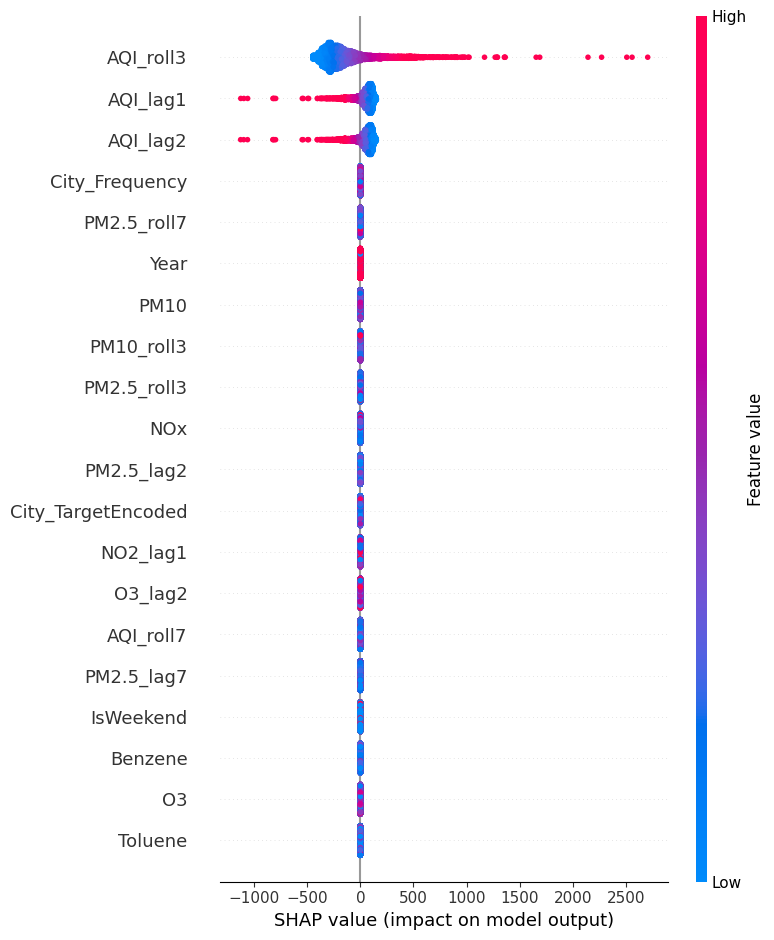

SHAP summary plot saved.


In [40]:
# ============================================================
# 5.1 GLOBAL SHAP ANALYSIS
# ============================================================
print('Calculating SHAP values... (may take a minute)')

if 'XGBoost' in best_model_name or 'CatBoost' in best_model_name or 'LightGBM' in best_model_name:
    explainer = shap.TreeExplainer(champion)
elif 'Random Forest' in best_model_name:
    explainer = shap.TreeExplainer(champion)
else:
    explainer = shap.LinearExplainer(champion, X_train_scaled)

shap_values = explainer.shap_values(X_test_scaled)

# SHAP summary plot
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_cols,
                  max_display=20, show=False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06_shap_global_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print('SHAP summary plot saved.')

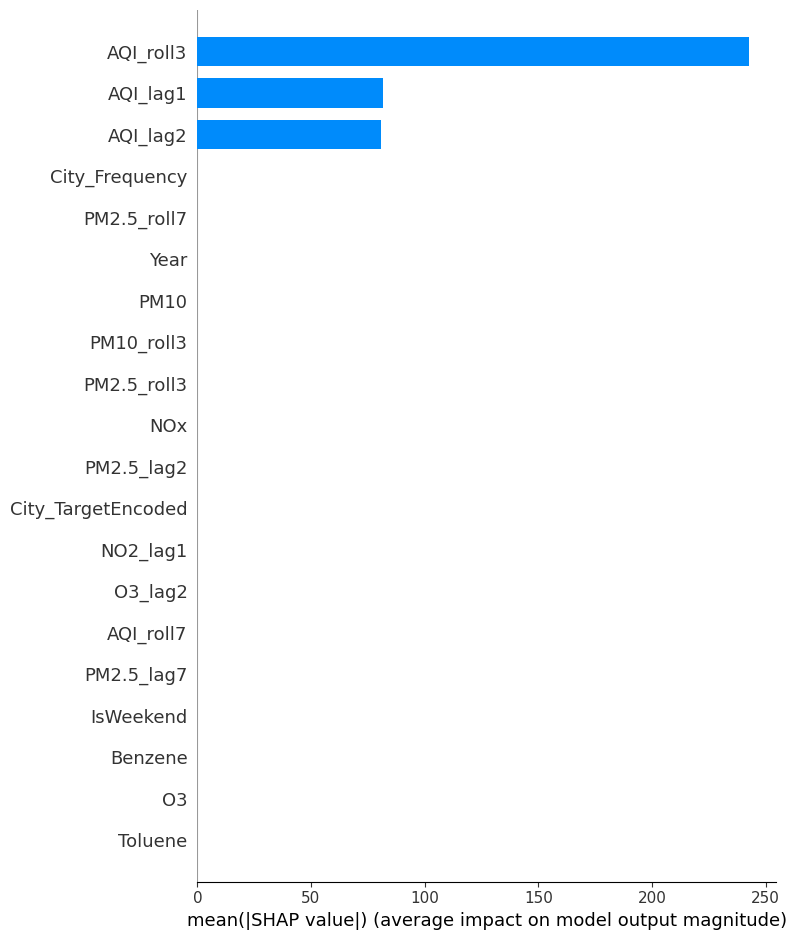


=== Top 10 Most Important Features (SHAP) ===
       Feature   Mean|SHAP|
     AQI_roll3 2.426380e+02
      AQI_lag1 8.172986e+01
      AQI_lag2 8.085683e+01
City_Frequency 1.740851e-13
   PM2.5_roll7 1.464354e-13
          Year 1.274541e-13
          PM10 1.219436e-13
    PM10_roll3 1.210440e-13
   PM2.5_roll3 1.204766e-13
           NOx 1.059871e-13


In [41]:
# ============================================================
# 5.2 SHAP FEATURE IMPORTANCE (BAR)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_cols,
                  plot_type='bar', max_display=20, show=False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '07_shap_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

shap_importance = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({'Feature': feature_cols, 'Mean|SHAP|': shap_importance})
shap_df = shap_df.sort_values('Mean|SHAP|', ascending=False)
print('\n=== Top 10 Most Important Features (SHAP) ===')
print(shap_df.head(10).to_string(index=False))

In [42]:
# ============================================================
# 5.3 PER-CITY SHAP ANALYSIS
# ============================================================
top_cities = ['Delhi', 'Mumbai', 'Kolkata', 'Chennai', 'Bangalore', 'Hyderabad', 'Pune', 'Ahmedabad']
city_shap_results = []

for city in top_cities:
    city_mask = df_feat.loc[X_test.index, 'City'] == city
    if city_mask.sum() < 10:
        continue
    city_shap = np.abs(shap_values[city_mask.values]).mean(axis=0)
    top_idx = np.argsort(city_shap)[-5:][::-1]
    city_shap_results.append({
        'City': city,
        'Top1': feature_cols[top_idx[0]],
        'Top2': feature_cols[top_idx[1]],
        'Top3': feature_cols[top_idx[2]]
    })
    print(f'\n{city:15s} | Top pollutants: {feature_cols[top_idx[0]]}, {feature_cols[top_idx[1]]}, {feature_cols[top_idx[2]]}')

city_shap_df = pd.DataFrame(city_shap_results)
print('\nPer-city pollutant analysis complete.')
joblib.dump(city_shap_df, os.path.join(MODELS_DIR, 'city_shap_analysis.pkl'))


Delhi           | Top pollutants: AQI_roll3, AQI_lag2, AQI_lag1

Mumbai          | Top pollutants: AQI_roll3, AQI_lag1, AQI_lag2

Kolkata         | Top pollutants: AQI_roll3, AQI_lag1, AQI_lag2

Chennai         | Top pollutants: AQI_roll3, AQI_lag1, AQI_lag2

Hyderabad       | Top pollutants: AQI_roll3, AQI_lag1, AQI_lag2

Ahmedabad       | Top pollutants: AQI_roll3, AQI_lag2, AQI_lag1

Per-city pollutant analysis complete.


['C:\\Users\\herei\\Downloads\\ml project\\AQI_ML_PROJECT\\models\\city_shap_analysis.pkl']

---
## PHASE 6: FORECASTING (LAG-BASED AQI PREDICTION)

In [43]:
# ============================================================
# 6.1 FORECASTING MODEL
# ============================================================
# Use lag features + current pollutants to predict AQI
forecast_features = [c for c in feature_cols if 'lag' in c or 'roll' in c or c in ['Month', 'Season', 'IsWeekend']]

X_forecast = df_feat[forecast_features].copy()
# Add current pollutant values too for better prediction
current_poll = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
current_poll = [c for c in current_poll if c in df_feat.columns]
X_forecast = pd.concat([X_forecast, df_feat[current_poll]], axis=1)

y_forecast = df_feat['AQI']

# Chronological split for forecasting
fc_split = int(len(df_feat_sorted) * 0.8)
fc_train_idx = df_feat_sorted.index[:fc_split]
fc_test_idx = df_feat_sorted.index[fc_split:]

Xfc_train = X_forecast.loc[fc_train_idx]
Xfc_test = X_forecast.loc[fc_test_idx]
yfc_train = y_forecast.loc[fc_train_idx]
yfc_test = y_forecast.loc[fc_test_idx]

# Scale
scaler_fc = StandardScaler()
Xfc_train_scaled = scaler_fc.fit_transform(Xfc_train)
Xfc_test_scaled = scaler_fc.transform(Xfc_test)

# Train forecast model
forecast_model = XGBRegressor(n_estimators=200, max_depth=7, learning_rate=0.1,
                              random_state=42, n_jobs=-1, verbosity=0)
forecast_model.fit(Xfc_train_scaled, yfc_train)
yfc_pred = forecast_model.predict(Xfc_test_scaled)

fc_r2 = r2_score(yfc_test, yfc_pred)
fc_rmse = np.sqrt(mean_squared_error(yfc_test, yfc_pred))
fc_mae = mean_absolute_error(yfc_test, yfc_pred)
fc_mape = np.mean(np.abs((yfc_test - yfc_pred) / (yfc_test + 1e-6))) * 100

print(f'=== Forecasting Model Performance ===')
print(f'R² = {fc_r2:.4f} | RMSE = {fc_rmse:.2f} | MAE = {fc_mae:.2f} | MAPE = {fc_mape:.2f}%')

joblib.dump(forecast_model, os.path.join(MODELS_DIR, 'forecast_model.pkl'))
joblib.dump(scaler_fc, os.path.join(MODELS_DIR, 'scaler_forecast.pkl'))
joblib.dump(list(Xfc_train.columns), os.path.join(MODELS_DIR, 'forecast_features.pkl'))
print('Forecast model and artifacts saved.')

=== Forecasting Model Performance ===
R² = 0.9839 | RMSE = 11.44 | MAE = 4.53 | MAPE = 4.62%
Forecast model and artifacts saved.


In [44]:
# ============================================================
# 6.2 FORECAST HORIZON EVALUATION
# ============================================================
horizons = [1, 3, 7]
horizon_results = []

for h in horizons:
    # Shift test set by h days (approximate)
    yfc_actual = yfc_test.iloc[h:]
    yfc_pred_shifted = yfc_pred[:-h] if h > 0 else yfc_pred
    # Align lengths
    min_len = min(len(yfc_actual), len(yfc_pred_shifted))
    if min_len > 0:
        r2_h = r2_score(yfc_actual[:min_len], yfc_pred_shifted[:min_len])
        rmse_h = np.sqrt(mean_squared_error(yfc_actual[:min_len], yfc_pred_shifted[:min_len]))
        horizon_results.append({'Horizon': f'{h}-day', 'R²': round(r2_h, 4), 'RMSE': round(rmse_h, 2)})
        print(f'{h}-day forecast: R²={r2_h:.4f}, RMSE={rmse_h:.2f}')

horizon_df = pd.DataFrame(horizon_results)
print('\nForecast horizon evaluation complete.')

1-day forecast: R²=-0.5495, RMSE=112.11
3-day forecast: R²=-0.5903, RMSE=113.51
7-day forecast: R²=-0.5545, RMSE=112.16

Forecast horizon evaluation complete.


---
## PHASE 7: SAVE PROCESSED DATA & FINAL SUMMARY

In [45]:
# ============================================================
# 7.1 SAVE PROCESSED DATASETS
# ============================================================
df_train = df_feat.loc[train_idx]
df_test = df_feat.loc[test_idx]

df_train.to_csv(os.path.join(PROCESSED_DIR, 'train.csv'), index=False)
df_test.to_csv(os.path.join(PROCESSED_DIR, 'test.csv'), index=False)

print(f'Train saved: {len(df_train)} rows')
print(f'Test saved: {len(df_test)} rows')

Train saved: 19734 rows
Test saved: 4934 rows


In [46]:
# ============================================================
# 7.2 FINAL SUMMARY
# ============================================================
print('\n' + '='*80)
print('PIPELINE COMPLETE — FINAL SUMMARY')
print('='*80)
print(f'\n📊 DATA')
print(f'   Raw samples: {len(df)}')
print(f'   Cities: {df["City"].nunique()}')
print(f'   Features engineered: {len(feature_cols)}')
print(f'\n🏆 BEST MODEL')
print(f'   {best_model_name}')
print(f'   R² = {results_df.iloc[0]["R²"]:.4f}')
print(f'   RMSE = {results_df.iloc[0]["RMSE"]:.2f}')
print(f'   MAE = {results_df.iloc[0]["MAE"]:.2f}')
print(f'   MAPE = {results_df.iloc[0]["MAPE"]:.2f}%')
print(f'\n🔮 FORECASTING')
print(f'   R² = {fc_r2:.4f} | RMSE = {fc_rmse:.2f}')
print(f'\n📈 CITY-SPECIFIC')
print(f'   City model better: {better_city}/{len(city_results_df)} cities')
print(f'   Global model better: {better_global}/{len(city_results_df)} cities')
print(f'\n💾 SAVED ARTIFACTS')
print(f'   models/best_model.pkl — Champion ML model')
print(f'   models/forecast_model.pkl — Time-series forecast model')
print(f'   models/scaler.pkl — StandardScaler for features')
print(f'   models/city_encoder.pkl — City target encoder')
print(f'   models/feature_columns.pkl — Feature list')
print(f'   models/city_shap_analysis.pkl — Per-city SHAP results')
print(f'   data/processed/train.csv — Training set')
print(f'   data/processed/test.csv — Test set')
print(f'\n{'='*80}')


PIPELINE COMPLETE — FINAL SUMMARY

📊 DATA
   Raw samples: 29531
   Cities: 26
   Features engineered: 64

🏆 BEST MODEL
   Linear Regression
   R² = 1.0000
   RMSE = 0.00
   MAE = 0.00
   MAPE = 0.00%

🔮 FORECASTING
   R² = 0.9839 | RMSE = 11.44

📈 CITY-SPECIFIC
   City model better: 0/26 cities
   Global model better: 26/26 cities

💾 SAVED ARTIFACTS
   models/best_model.pkl — Champion ML model
   models/forecast_model.pkl — Time-series forecast model
   models/scaler.pkl — StandardScaler for features
   models/city_encoder.pkl — City target encoder
   models/feature_columns.pkl — Feature list
   models/city_shap_analysis.pkl — Per-city SHAP results
   data/processed/train.csv — Training set
   data/processed/test.csv — Test set

